In [1]:
# Base model imports
import sys
sys.path.append('../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_dynamics as perturbation_dynamics_base,
    I0 as I0_base,
    PARAMETER_NAMES as PARAMETER_NAMES_base,
    equation as equation_base
)

# Extended model imports
from multi_nutrient_model_ext import (
    ref_parameters as ref_parameters_ext,
    perturbation_dynamics as perturbation_dynamics_ext,
    I0 as I0_ext,
    PARAMETER_NAMES as PARAMETER_NAMES_ext,
    equation as equation_ext,
    AMINO_ACIDS
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve

# Set plotting style to match type_I_diabetes_comp.ipynb
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

## Parameters and Perturbation Range

Setup common parameters and energy demand perturbation range (1/3x to 3x baseline).

In [2]:
# Common parameters
K_i_ketogenesis = 0.2

# Perturbation range for energy demand
perturbations = np.logspace(np.log10(1/3), np.log10(3), 100)

# Time for dynamics to reach steady state
time_dyn = np.linspace(0, 100, 100)

# Steady state tolerance
tol = 1e-4

print(f"Energy demand range: {perturbations.min():.3f}x to {perturbations.max():.3f}x")
print(f"Number of perturbations: {len(perturbations)}")


def compute_steady_states(model_type, param_name, perturbations, K_i_ketogenesis=0.2, time_dyn=time_dyn, tol=1e-4):
    """
    Compute steady states for varying energy demand with WT and KO conditions.
    
    Parameters
    ----------
    model_type : str
        'base' or 'extended'
    param_name : str
        Parameter name for knockout, e.g., 'insulin_action_glycolysis'
    perturbations : array
        Array of energy demand multipliers
    K_i_ketogenesis : float
        Ketogenesis inhibition constant
    time_dyn : array
        Time points for dynamics simulation
    tol : float
        Tolerance for steady state convergence
        
    Returns
    -------
    DataFrame with columns: perturbation, Glucose, Insulin, steady, failed, condition, model
    """
    # Select model-specific functions based on model_type
    if model_type == 'base':
        ref_parameters = ref_parameters_base
        perturbation_dynamics = perturbation_dynamics_base
        PARAMETER_NAMES = PARAMETER_NAMES_base
        equation = equation_base
        I0 = I0_base
        model_label = 'Base'
    elif model_type == 'extended':
        ref_parameters = ref_parameters_ext
        perturbation_dynamics = perturbation_dynamics_ext
        PARAMETER_NAMES = PARAMETER_NAMES_ext
        equation = equation_ext
        I0 = I0_ext
        model_label = 'Extended'
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    
    records = []
    
    for condition_val in [True, False]:
        # Create parameters with the specified insulin action knockout
        p = ref_parameters(K_i_ketogenesis=K_i_ketogenesis, **{param_name: condition_val})
        vE0 = p[PARAMETER_NAMES.index('v_energy')]
        
        for v in perturbations:
            # Run dynamics
            try:
                if model_type == 'base':
                    X_trace, _ = perturbation_dynamics(time_dyn, 1.0, p=p, v_energy=vE0 * v)
                else:
                    X_trace, _ = perturbation_dynamics(time_dyn, p=p, v_energy=vE0 * v)
                failed = False
            except Exception:
                records.append({
                    'perturbation': v,
                    'Glucose': np.nan,
                    'Insulin': np.nan,
                    'steady': False,
                    'failed': True,
                    'condition': 'WT' if condition_val else 'KO',
                    'model': model_label
                })
                continue
            
            # Get endpoint and check if at steady state
            x_end = X_trace.iloc[-1, :-1].values
            p_pert = p.copy()
            p_pert[PARAMETER_NAMES.index('v_energy')] = vE0 * v
            
            if model_type == 'base':
                dx = equation(x_end, 1.0, p_pert)
            else:
                dx = equation(0, x_end, p_pert)
            dyn_residual = np.max(np.abs(dx))
            
            # If dynamic endpoint is not at steady state, use fsolve to refine
            if dyn_residual >= tol:
                if model_type == 'base':
                    def ss_eq(x):
                        return equation(x, 1.0, p_pert)
                else:
                    def ss_eq(x):
                        return equation(0, x, p_pert)
                
                x_ss, info, ier, mesg = fsolve(ss_eq, x_end, full_output=True, xtol=tol)
                ss_residual = np.max(np.abs(info['fvec']))
                if ier == 1 and np.all(x_ss >= 0) and ss_residual < tol:
                    x_end = x_ss
                    steady = True
                else:
                    steady = False
            else:
                steady = True
            
            records.append({
                'perturbation': v,
                'Glucose': x_end[1] * 7,  # G is index 1, convert to mM
                'Insulin': x_end[4] / I0,  # I is index 4, normalize to basal
                'steady': steady,
                'failed': False,
                'condition': 'WT' if condition_val else 'KO',
                'model': model_label
            })
    
    df = pd.DataFrame(records)
    df = df.loc[~df['failed'] & df['steady']].reset_index(drop=True)
    return df

Energy demand range: 0.333x to 3.000x
Number of perturbations: 100


## 1. Glycolysis Activation Knockout

Test the effect of removing insulin activation of glycolysis (K_a_glycolysis).

In [3]:
# Glycolysis activation knockout - both models
print("Computing glycolysis activation knockout...")

df_base_glyc = compute_steady_states('base', 'insulin_action_glycolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Base model: {len(df_base_glyc)} valid steady states")

df_ext_glyc = compute_steady_states('extended', 'insulin_action_glycolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Extended model: {len(df_ext_glyc)} valid steady states")

df_glyc = pd.concat([df_base_glyc, df_ext_glyc], axis=0, ignore_index=True)

Computing glycolysis activation knockout...
✓ Base model: 200 valid steady states
✓ Extended model: 200 valid steady states


## 2. Lipolysis Inhibition Knockout

Test the effect of removing insulin inhibition of lipolysis (K_i_lipolysis).

In [4]:
# Lipolysis inhibition knockout - both models
print("Computing lipolysis inhibition knockout...")

df_base_lipo = compute_steady_states('base', 'insulin_action_lipolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Base model: {len(df_base_lipo)} valid steady states")

df_ext_lipo = compute_steady_states('extended', 'insulin_action_lipolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Extended model: {len(df_ext_lipo)} valid steady states")

df_lipo = pd.concat([df_base_lipo, df_ext_lipo], axis=0, ignore_index=True)

Computing lipolysis inhibition knockout...
✓ Base model: 192 valid steady states
✓ Extended model: 193 valid steady states


## 3. Ketogenesis Inhibition Knockout

Test the effect of removing insulin inhibition of ketogenesis (K_i_ketogenesis action).

In [5]:
# Ketogenesis inhibition knockout - both models
print("Computing ketogenesis inhibition knockout...")

df_base_keto = compute_steady_states('base', 'insulin_action_ketogenesis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Base model: {len(df_base_keto)} valid steady states")

df_ext_keto = compute_steady_states('extended', 'insulin_action_ketogenesis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Extended model: {len(df_ext_keto)} valid steady states")

df_keto = pd.concat([df_base_keto, df_ext_keto], axis=0, ignore_index=True)

Computing ketogenesis inhibition knockout...
✓ Base model: 200 valid steady states
✓ Extended model: 200 valid steady states


## Comparison Plots

Plot glucose response for each knockout, comparing base vs extended models.

## Glycogenolysis Inhibition by Insulin

Test the effect of insulin action on glycogenolysis.

In [6]:
# Glycogenolysis inhibition knockout - both models
print("Computing glycogenolysis inhibition knockout...")

df_base_glycogen = compute_steady_states('base', 'insulin_action_glycogenolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Base model: {len(df_base_glycogen)} valid steady states")

df_ext_glycogen = compute_steady_states('extended', 'insulin_action_glycogenolysis', perturbations, K_i_ketogenesis=K_i_ketogenesis)
print(f"✓ Extended model: {len(df_ext_glycogen)} valid steady states")

df_glycogen = pd.concat([df_base_glycogen, df_ext_glycogen], axis=0, ignore_index=True)

Computing glycogenolysis inhibition knockout...
✓ Base model: 200 valid steady states
✓ Extended model: 200 valid steady states


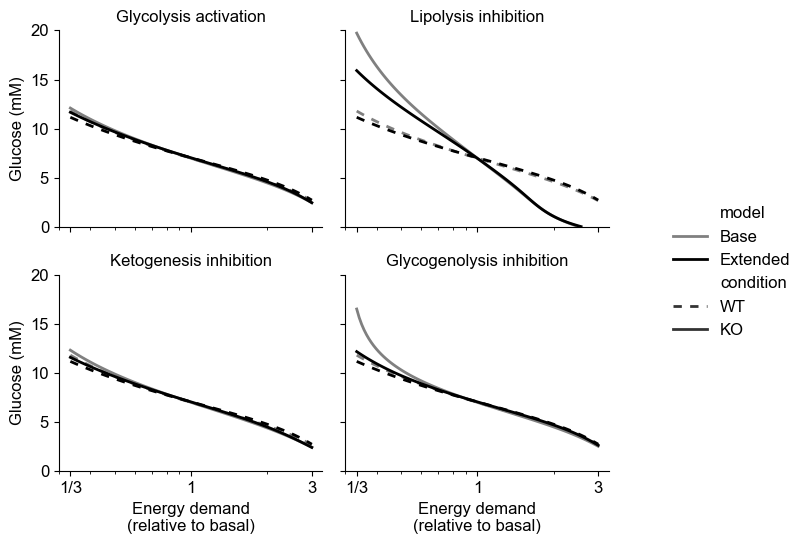

In [7]:
# Prepare combined data for faceted plotting
df_glyc['knockout'] = 'Glycolysis activation'
df_lipo['knockout'] = 'Lipolysis inhibition'
df_keto['knockout'] = 'Ketogenesis inhibition'
df_glycogen['knockout'] = 'Glycogenolysis inhibition'

plot_data = pd.concat([df_glyc, df_lipo, df_keto, df_glycogen], axis=0, ignore_index=True)

# Create combined group for plotting
plot_data['group'] = plot_data['model'] + ' ' + plot_data['condition']

# Create FacetGrid with 2x2 layout
g = sns.FacetGrid(plot_data, col="knockout", col_wrap=2, height=2.8, aspect=0.9,
                  sharey=True, sharex=True,
                  col_order=['Glycolysis activation', 'Lipolysis inhibition', 
                             'Ketogenesis inhibition', 'Glycogenolysis inhibition'])

# Map lineplot with hue and style
g.map_dataframe(sns.lineplot, x="perturbation", y="Glucose", 
                hue='model', style='condition',
                hue_order=['Base', 'Extended'],
                style_order=['WT', 'KO'],
                palette={'Base': 'grey', 'Extended': 'black'},
                dashes={'WT': (3, 3), 'KO': ''}, linewidth=2)

# Set x-axis to log scale
for ax in g.axes:
    ax.set_xscale('log')
    ax.set_xticks([1/3, 1, 3])
    ax.set_xticklabels(['1/3', '1', '3'])
    ax.set_xlim(1/3 * 0.9, 3 * 1.1)

# Set y-axis limits
for ax in g.axes:
    ax.set_ylim(0, 20)
    ax.set_ylabel("Glucose (mM)")
    ax.set_xlabel("Energy demand\n(relative to basal)")

g.set_titles(col_template="{col_name}")
g.add_legend(title='', bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
sns.despine()
plt.savefig('./output/insulin_action_comparison.svg', bbox_inches='tight')
plt.show()

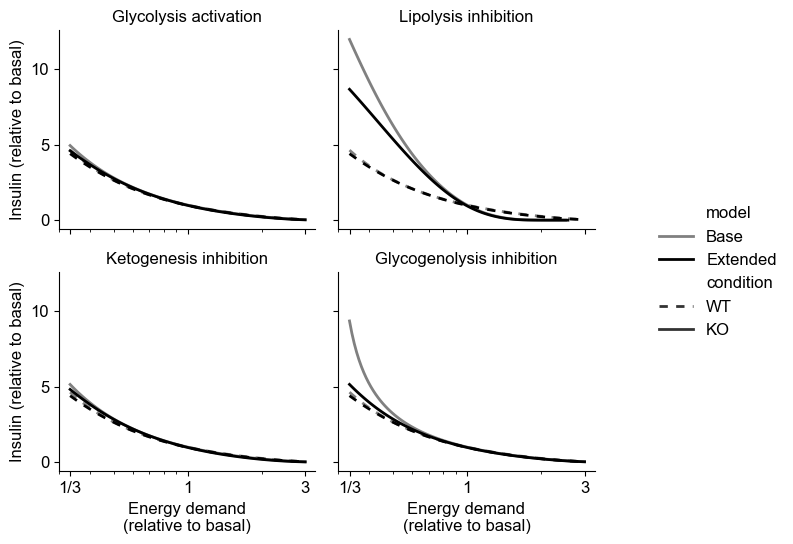

In [8]:
# Plot Insulin response for each knockout
# Create FacetGrid with 2x2 layout for Insulin
g_ins = sns.FacetGrid(plot_data, col="knockout", col_wrap=2, height=2.8, aspect=0.9,
                      sharey=True, sharex=True,
                      col_order=['Glycolysis activation', 'Lipolysis inhibition', 
                                 'Ketogenesis inhibition', 'Glycogenolysis inhibition'])

# Map lineplot with hue and style
g_ins.map_dataframe(sns.lineplot, x="perturbation", y="Insulin", 
                    hue='model', style='condition',
                    hue_order=['Base', 'Extended'],
                    style_order=['WT', 'KO'],
                    palette={'Base': 'grey', 'Extended': 'black'},
                    dashes={'WT': (3, 3), 'KO': ''}, linewidth=2)

# Set x-axis to log scale
for ax in g_ins.axes:
    ax.set_xscale('log')
    ax.set_xticks([1/3, 1, 3])
    ax.set_xticklabels(['1/3', '1', '3'])
    ax.set_xlim(1/3 * 0.9, 3 * 1.1)

# Set y-axis label
for ax in g_ins.axes:
    ax.set_ylabel("Insulin (relative to basal)")
    ax.set_xlabel("Energy demand\n(relative to basal)")

g_ins.set_titles(col_template="{col_name}")
g_ins.add_legend(title='', bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
sns.despine()
plt.savefig('./output/insulin_action_comparison_insulin.svg', bbox_inches='tight')
plt.show()